In [1]:
import pandas as pd 
from matplotlib import pyplot as plt
from matplotlib import gridspec as gridspec
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from pathlib import Path
import numpy as np

plt.style.use('seaborn-darkgrid')

## input folder (relatief gezien vanaf locatie van dit script) 
input_folder = 'data/adjusted for doubles/'

## spike calling method
# use percentage based threshold of the data distribution instead of a global/local method, if on global/local will not be used! --- default: False
percentage_based_threshold = False
# percentage of data distribution for simple method --- default: 0.99 (min 0.00 & max 1.00)
percentage_threshold = 0.95
# global standard deviation (stddev) based on data, threshold can be set to n times the stddev --- default: 3 (recommended: multiplier not lower than 2.5, needs optimalisation)
global_standard_deviation_threshold_multiplier = 3
# under noise standard deviation based on data and global stddev multiplier, threshold can be set to n times the stddev --- default: 5 (needs optimalisation)
under_noise_standard_deviation_threshold_multiplier = 5

## spike calling settings
# how many seconds to wait after a spike peak has been to defined before another spike can start to be defined --- default: 3 (needs optimalisation)
spike_offset_time = 3
# time offset in seconds to detect overlap in spikes from other video (as measurements are not on the exact same time scale) --- default: 0.2 (needs optimalisation)
nb_time_offset = 1

## network burst detection settings
# percentage of how many traces are required to contribute to a Network Burst (NB) to have it count for plotting and statistics --- default: 0.3 (30%, depends on data, n_traces per group) 
n_traces_for_NB_per_group_percentage_threshold = 0.3
# absolute amount of traces that are required to contribute to a Network Burst (NB) to have it count for plotting and statistics --- default: 2 (minimally 1, needs optimalisation)
n_traces_for_NB_per_group_threshold = 2

## plotting settings
# quality control plots, used to check if using stddev_threshold made sense --- default: False
to_plot_distributions = False
# plot equal trace lengths for neatness or false to show each individual trace length --- default: False (Not needed now every group gets its own subplot)
show_equal_trace_length = False

In [31]:
data = Path(input_folder).glob('*.xlsx')
dataframes = []

for xlsx in data:
    df = pd.read_excel(xlsx, index_col = 0, engine = 'openpyxl')
    # renaming df index for clarity and brevity 
    index = []
    raw_smooth = 'smooth'
    for name in df.index.values.tolist():
        if 'raw' in name:
            raw_smooth = 'raw'
        # keep well.video.neuronID
        name = name.split(' ')[1]
        index.append('{}.{}'.format(name, raw_smooth))
    df.index = index
    dataframes.append(df)

# merge all dataframes from separate .xlsx files 
df_merged = pd.DataFrame()
for df in dataframes:
    df_merged = df_merged.append(df)
df = df_merged.T

# DEVNOTE: removed all raw columns, for now not working with raw data! 
for name in df.columns:
    if 'raw' in name:
        del df[name]

1.1.1
1.1.1
1.1.2
1.1.2
1.1.3
1.1.3
1.1.4
1.1.4
1.1.5
1.1.5
1.1.1
1.1.1
1.1.2
1.1.2
1.1.3
1.1.3
1.1.4
1.1.4
1.1.5
1.1.5
1.2.1
1.2.1
1.2.2
1.2.2
1.2.3
1.2.3
1.2.4
1.2.4
1.2.5
1.2.5
1.2.1
1.2.1
1.2.2
1.2.2
1.2.3
1.2.3
1.2.4
1.2.4
1.2.5
1.2.5
1.3.1
1.3.1
1.3.2
1.3.2
1.3.3
1.3.3
1.3.4
1.3.4
1.3.5
1.3.5
1.3.6
1.3.6
1.3.1
1.3.1
1.3.2
1.3.2
1.3.3
1.3.3
1.3.4
1.3.4
1.3.5
1.3.5
1.3.6
1.3.6
1.4.1
1.4.1
2.1.1
2.1.1
2.1.2
2.1.2
2.1.3
2.1.3
2.1.1
2.1.1
2.1.2
2.1.2
2.1.3
2.1.3
2.2.1
2.2.1
2.2.2
2.2.2
2.2.3
2.2.3
2.2.1
2.2.1
2.2.2
2.2.2
2.2.3
2.2.3
2.3.1
2.3.1
2.3.2
2.3.2
2.3.1
2.3.1
2.3.2
2.3.2
2.4.2
2.4.2
2.4.2
2.4.2


PermissionError: [Errno 13] Permission denied: 'data\\adjusted for doubles\\~$well1_video1.xlsx'

In [3]:
def define_spikes(df, global_sd_multiplier = 3, under_noise_sd_multiplier = 3, spike_offset = 0.5, percentage_based_threshold = True, percentage = 0.99):
    start = []
    peak = []
    # end = [] # DEPRECATED, peak are new ends 
    index = []
    stats_index = []
    stats_n_spikes = []
    stats_spikes_time = []
    stats_seconds_measured = []
    threshold_data = []
    threshold_indices = []
    for (col, data) in df.iteritems():
        # create numpy data to enable masking
        npdata = np.array(df[col]).astype(np.double)
        # create mask to obtain pure trace data
        mask = np.isfinite(npdata)

        # use simple percentage based on data distribution method or mediocre sophisticated global/local threshold 
        if percentage_based_threshold:
            sorted_data = data[mask].sort_values()
            threshold_index = int(percentage*len(data[mask]))
            threshold = sorted_data.iloc[threshold_index]
        else:
            # define 'global' standard deviation - global meaning for whole trace data
            global_stddev = np.std(df[col][mask])
            # define noise threshold
            noise_threshold = global_stddev * global_sd_multiplier
            # data under noise threshold, used to calculate under noise stddev
            under_noise_threshold = data[mask] < noise_threshold
            # define under noise data stddev from all data under noise threshold
            under_noise_stddev = np.std(data[mask][under_noise_threshold])
            # define threshold 
            threshold = under_noise_stddev * under_noise_sd_multiplier

        # save threshold for plotting
        threshold_data.append(threshold)
        # trace name
        threshold_indices.append(col)

        # add a starting point when start_possible and peak_possible and value > threshold
        # add peak when trace starting to decreaes, peak_possible and not start_possible 
        # reset peak_possible and start_possible to true when enough time passed (spike_offset) after peak detected 
        count = 0
        old_value = 0
        peak_value = 0 
        peak_index = 0
        peak_possible = True
        start_possible = True
        for (idx, value) in data[mask].iteritems():
            increasing = value > old_value
            if value > threshold:
                # print(idx, value, peak_index - idx)
                
                if increasing == True and peak_possible == True: 
                    peak_value = value 
                    peak_index = idx
                    if start_possible == True:
                        # print('first over threshold')
                        start.append(idx)
                        start_possible = False
            if increasing == False and peak_possible == True and start_possible == False:
                # print('peak found')
                # peak found, add as spike 
                peak_possible = False
                peak.append(peak_index)
                index.append(col)
                count += 1
            if increasing == False and (idx - peak_index) > spike_offset and start_possible == False and peak_possible == False:
                # print('reset for time')
                peak_possible = True
                start_possible = True
            if value < threshold and (idx - peak_index) > spike_offset and start_possible == False and peak_possible == False:
                # print('reset for threshold')
                peak_possible = True
                start_possible = True
            # set to check if trace increasing or decreasing  
            old_value = value

        # extract stats - where idx = total measure time per video
        stats_index.append(col)
        stats_n_spikes.append(count)
        stats_spikes_time.append((count/idx) * 60)
        stats_seconds_measured.append(idx)
        
        # # sometimes a spike did not recover ('end') as measuring was cut off, append closing time to ends
        if len(start) > len(peak):
            peak.append(idx)
            index.append(col)

    threshold_data = {'threshold': threshold_data}
    df_threshold = pd.DataFrame(data = threshold_data, index = threshold_indices)

    # initiate stats data to create data frame
    stats_data = {'n_spikes': stats_n_spikes, 'spikes_per_minute': stats_spikes_time, 'seconds_measured': stats_seconds_measured}
    # create spike stats dataframe
    df_stats = pd.DataFrame(data = stats_data, index = stats_index)

    data = {'start': start, 'end': peak}
    df_spikes = pd.DataFrame(data = data, index = index)
    
    return df_spikes, df_stats, df_threshold
            
df_spikes, df_stats_spikes, df_threshold = define_spikes(df, global_sd_multiplier = global_standard_deviation_threshold_multiplier, under_noise_sd_multiplier = under_noise_standard_deviation_threshold_multiplier, spike_offset = spike_offset_time, percentage_based_threshold = percentage_based_threshold, percentage = percentage_threshold)
    

In [4]:

## DEPRECATED: leave existing while implementing new solution and see if it really works! 
# def check_network_bursts(df_spikes, time_offset, n_traces_for_NB_per_group_threshold):
#     df = df_spikes['start']

#     # initiate dictionary with value information per 'group' (well, video, raw_smooth)
#     iterdict = {}
#     # initiate dictionary with amount of network_bursts
#     stats_traces = {}
#     stats_groups = {}
#     # fill iterdict by grouping values
#     for (name, value) in df.iteritems():
#         # get keys for dict 
#         well = int(name.split('.')[0])
#         video = int(name.split('.')[1])
#         trace = int(name.split('.')[2])
#         raw_smooth = name.split('.')[3]
#         # initiate dict grouping with keys/values 
#         if not well in iterdict.keys():
#             iterdict[well] = {}
#         if not video in iterdict[well].keys():
#             iterdict[well][video] = {}
#         if not raw_smooth in iterdict[well][video].keys():
#             iterdict[well][video][raw_smooth] = {}
#         if not trace in iterdict[well][video][raw_smooth].keys():
#             iterdict[well][video][raw_smooth][trace] = []
#         iterdict[well][video][raw_smooth][trace].append(value)

#         # initiate stats dicts with 0 network bursts for each trace and group 
#         if name not in stats_traces.keys():
#             stats_traces[name] = 0
#             stats_groups['{}.{}'.format(well, video)] = 0
        
#     def evaluate_old_group_hits(hits, n_traces_in_group):
#         print("NEW GROUP")
#         # sort hits
#         hits['start'], hits['name'] = (list(l) for l in zip(*sorted(zip(hits['start'], hits['name']))))

#         # initiate remaining hits that will be returned for plotting
#         remaining_hits = {'name': [], 'start': []}
#         # initiate with first name and start_time 
#         old_name = hits['name'][0]
#         old_start = hits['start'][0]
#         # save names temporarily while counting to go over percentage threshold reached for minimal amount of traces contributing to network burst 
#         temp_names = []

#         # TODO should spike ends be taken in to account for better NB detection? 

#         # TODO check prints, first of new group seems to be skipped but gets added in print 3 as initiate of temp_names = [name]
#         ## values and traces obviously missing, like 1.1.2
#         ## also check 3 1.1.4.smooth 65.92845
#                     # 1 1.1.5.smooth 65.92845
#                     # 3 1.1.1.smooth 66.183
#                     # 2 1.1.3.smooth 66.183    time difference is allowed but doesn't make sense based on plot, check when spike defined if this makes sense? 

#         # TODO check for a grouped solution with query, instead of checking value by vlue and trace by trace 

#         for name, start in zip(hits['name'], hits['start']):
#             # remove duplicates - if same name occurs twice in sorted by time order, skip it 
#             if name == old_name and start > old_start - time_offset and start < old_start + time_offset:
#                 print(1, name, start)
#                 pass
#             elif start > old_start - time_offset and start < old_start + time_offset:
#                 print(2, name, start)
#                 temp_names.append(name)
#             else:
#                 print(3, name, start)
#                 # process old group
#                 if len(temp_names)/n_traces_in_group > n_traces_for_NB_per_group_threshold:
#                     for name in temp_names:
#                         stats_traces[name] += 1
#                         remaining_hits['name'].append(name)
#                         remaining_hits['start'].append(start)
#                     well = int(name.split('.')[0])
#                     video = int(name.split('.')[1])
#                     stats_groups['{}.{}'.format(well, video)] += 1
#                 # initiate new group
#                 temp_names = [name]
#             old_name = name
#             old_start = start 
        
#         # process final group
#         if len(temp_names) > 1 and len(temp_names)/n_traces_in_group > n_traces_for_NB_per_group_threshold:
#             for name in temp_names:
#                 stats_traces[name] += 1
#                 remaining_hits['name'].append(name)
#                 remaining_hits['start'].append(start)
#             well = int(name.split('.')[0])
#             video = int(name.split('.')[1])
#             stats_groups['{}.{}'.format(well, video)] += 1
#         return remaining_hits







#     # TODO check remaining summary statistics errors where <1 for #spikes and #NBs theoretically not possible 
#     ## go over with prints per trace in group that goes <1 

#     # TODO spike_ends for NB detection
#     # TODO n_spikes < n_bursts for 1 trace impossible 

#     # initiate hits dict (network burst per group per trace are added in here for extraction --> plotting)
#     all_hits = {'name': [], 'start': []}
#     group_hits = {'name': [], 'start': []}
#     # need dict per value_hits to see if x.x.1 does not get added in double
#     value_hits = {'name': [], 'start': []}
#     old_video_num = 1
    
#     # loop iterdict to compare all 'grouped' (well, video, raw_smooth) traces for overlap (network bursts) in values
#     for well in iterdict.keys():
#         for video in iterdict[well].keys():
#             # if next group found evaluate and add to all_hits for plotting
#             if video != old_video_num:
#                 old_group_hits = evaluate_old_group_hits(group_hits, n_traces_in_group)
#                 all_hits['name'] += old_group_hits['name']
#                 all_hits['start'] += old_group_hits['start']
#             # reset for new group
#             old_video_num = video
#             group_hits = {'name': [], 'start': []}
#             for r_s in iterdict[well][video].keys():
#                 # get total amount of traces in group (and type)
#                 n_traces_in_group = len(iterdict[well][video][r_s].keys())
#                 for trace in iterdict[well][video][r_s].keys():
#                     # remove trace itself from other traces to compare values of itself onto only the other for network bursts 
#                     other_traces = list(iterdict[well][video][r_s].keys())
#                     other_traces.remove(trace) 
#                     for val1 in iterdict[well][video][r_s][trace]:
#                         for trace2 in other_traces:
#                             for val2 in iterdict[well][video][r_s][trace2]:
#                                 # check only if trace < trace2 (no need for double+ network_burst entries)
#                                 # check if value from trace 1 in range around value of trace 2 (start time time_offset)
#                                 # TODO this is where to implement spike_ends
#                                 if trace2 > trace and val1 > val2 - time_offset and val1 < val2 + time_offset:
#                                     name1 = '{}.{}.{}.{}'.format(well, video, trace, r_s)
#                                     name2 = '{}.{}.{}.{}'.format(well, video, trace2, r_s)
                                    
#                                     add1, add2 = True, True
#                                     # get indices where val1 in group_hits['start]
#                                     indices = [i for i, x in enumerate(group_hits['start']) if x == val1]
#                                     indices2 = [i for i, x in enumerate(group_hits['start']) if x == val2]
#                                     # check if combination of (name, start) already in group_hits, if so, flag to false to do not add to value_hits 
#                                     for i in indices + indices2:
#                                         if group_hits['name'][i] == name1:
#                                             add1 = False
#                                         if group_hits['name'][i] == name2:
#                                             add2 = False
                                    


#                                     # PRINT TESTING CODE, REMOVE AFTER FIX
#                                     if '{}.{}'.format(well, video) == '1.1' and 20 < val1 < 40:
#                                         print(name1, name2, val1, val2, add1, add2)
#                                         print()



#                                     if add1:
#                                         group_hits['name'].append(name1)
#                                         group_hits['start'].append(val1)
#                                     if add2: 
#                                         group_hits['name'].append(name2)
#                                         group_hits['start'].append(val2)
#                                     # don't check other values of same trace2 if match found, go to next trace (speeds up code)
#                                     break

#     # final group evaluation if hits found
#     if group_hits['name'] != []:
#         group_hits = evaluate_statistics(group_hits, n_traces_in_group)
#         all_hits['name'] += group_hits['name']
#         all_hits['start'] += group_hits['start'] 

#     # create NB stats dataframe 
#     df_stats_network_bursts = pd.DataFrame(data = list(stats_traces.values()), index = list(stats_traces.keys()), columns = ['n_network_bursts'])
#     # add amount of network bursts per group to NB stats
#     n_network_bursts_group = []
#     for name in df_stats_network_bursts.index:
#         well = int(name.split('.')[0])
#         video = int(name.split('.')[1])
#         index = '{}.{}'.format(well, video)
#         n_network_bursts_group.append(stats_groups[index])
#     df_stats_network_bursts['n_network_bursts_group'] = n_network_bursts_group

#     print(df_stats_network_bursts)

#     # create hits dataframe for plotting
#     df_hits = pd.DataFrame(data = all_hits['start'], index = all_hits['name'], columns = ['start'])
    
#     return df_hits, df_stats_network_bursts

# df_network_bursts, df_stats_network_bursts = check_network_bursts(df_spikes, time_offset = nb_time_offset, n_traces_for_NB_per_group_threshold = n_traces_for_NB_per_group_threshold)


In [5]:
def define_network_bursts(df_spikes, nb_time_offset, n_traces_for_NB_per_group_percentage_threshold, n_traces_for_NB_per_group_threshold):
    # initiate information loop and statistics dictionaries 
    nb_info = {}
    nb_group_stats = {}
    nb_trace_stats = {}
    for ind in df_spikes.index:
        well = int(ind.split('.')[0])
        video = int(ind.split('.')[1])
        trace = int(ind.split('.')[2])
        group = '{}.{}'.format(well, video)
        if group not in nb_info.keys():
            nb_info[group] = 0
            nb_group_stats[group] = 0
            old_trace = 0
        if trace != old_trace:
            nb_info[group] += 1
            nb_trace_stats[ind] = 0
        old_trace = trace 
    
    # initiate all NB hits dictionary for plotting NBs later 
    all_hits = {'name': [], 'start': []}
    # loop for each group: g.g.x
    for group in nb_info.keys():
        # get group data in df
        df_group = df_spikes[df_spikes.index.str.startswith(group)]
        # while df_group is not empty, take first value and query
        while not df_group.empty:
            val = df_group['start'][0]
            # # check if spike values of all traces within group lie within range based on NB time offset 
            nb_values = df_group.query('@val - @nb_time_offset < start < @val + @nb_time_offset')
            df_group = df_group[~df_group['start'].between(val-nb_time_offset, val+nb_time_offset, inclusive=False)]
            n_traces = 0
            for nb_ind in nb_values.index:
                n_traces += 1
            if n_traces/nb_info[group] >= n_traces_for_NB_per_group_percentage_threshold and n_traces > n_traces_for_NB_per_group_threshold:
                nb_group_stats[group] += 1
                for nb_ind, nb_start in zip(nb_values.index, nb_values['start']):
                    nb_trace_stats[nb_ind] += 1
                    all_hits['name'].append(nb_ind)
                    all_hits['start'].append(nb_start)

    # create NB stats data frame with per trace and per group values  
    df_stats_network_bursts = pd.DataFrame(data = list(nb_trace_stats.values()), index = list(nb_trace_stats.keys()), columns = ['n_trace_NBs'])
    n_group_NBs = []
    for name in df_stats_network_bursts.index:
        well = int(name.split('.')[0])
        video = int(name.split('.')[1])
        index = '{}.{}'.format(well, video)
        n_group_NBs.append(nb_group_stats[index])
    df_stats_network_bursts['n_group_NBs'] = n_group_NBs

    # create hits dataframe for plotting
    df_hits = pd.DataFrame(data = all_hits['start'], index = all_hits['name'], columns = ['start'])

    return df_hits, df_stats_network_bursts

df_network_bursts, df_stats_network_bursts = define_network_bursts(df_spikes, nb_time_offset = nb_time_offset, n_traces_for_NB_per_group_threshold = n_traces_for_NB_per_group_threshold)

In [6]:
def plot_distribution(df, type, well):
    custom_colors = [(0,0,0), (146,0,0), (73,0,146), (219,109,0), (0,109,219), (182,109,255), (182,219,255), (146,0,0), (109,182,255), 
                         (36,255,36), (255,182,219), (0,73,73), (255,255,109), (146,73,0), (255,109,182), (58,58,0), (0,146,146)]

    # calculate how many traces within condition (correct well and type)
    nrows = 0
    for col in df.columns:
        if well == int(col.split('.')[0]) and type == col.split('.')[3]:
            nrows += 1

    # instantiate plot 
    fig, axes = plt.subplots(nrows = nrows, ncols = 1, sharex=True, figsize=(25, 20))
    plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=None, hspace=0.05)
    plt.suptitle('Distribution - All videos, well: {}, type: {}'.format(well, type), fontsize=24)
    # xlabel
    fig.text(0.5, 0.04, 'Timepoints (s)', ha='center', fontsize=24)
    # ylabel
    fig.text(0.04, 0.5, 'Occurence (%)', va='center', rotation='vertical', fontsize=24)

    nrow = 0
    for col in df.columns:
        if well == int(col.split('.')[0]) and type == col.split('.')[3]:
            # get color from color blind friendly color list (custom)
            color = list(map(lambda x: x/255, custom_colors[int(col.split('.')[1])]))
            
            # get xdata 
            xdata = np.array(df[col]).astype(np.double)
            xmask = np.isfinite(xdata)

            # plot data 
            axes[nrow].hist(xdata[xmask], bins = 10, label = col, color=color)
            
            # bump index for plotting in correct matplotlib plot figure axes
            nrow += 1

    # add legend
    fig.legend(prop={'size': 20})
    # save plot
    fig.savefig('plots/Distribution-Well_{}-Type_{}'.format(well, type))


In [7]:
def plot_traces(df, type, well, spikes, network_bursts, thresholds, show_equal_trace_length = True):
    custom_colors = [(0,0,0), (146,0,0), (73,0,146), (219,109,0), (0,109,219), (182,109,255), (182,219,255), (146,0,0), (109,182,255), 
                         (36,255,36), (255,182,219), (0,73,73), (255,255,109), (146,73,0), (255,109,182), (58,58,0), (0,146,146)]

    # calculate how many traces within condition (correct well and type)
    nrows = 0
    last_valid_trace_indices = []
    for col in df.columns:
        if well == int(col.split('.')[0]) and type == col.split('.')[3]:
            nrows += 1
            # from col grab last value, check with index at what final time that is, plot all traces to minimal final time 
            last_valid_trace_indices.append(df[col].last_valid_index())
    minimal_last_trace_index = min(last_valid_trace_indices)

    # for specific well, get amount of groups based on final trace of well 
    group_trace = {}
    group_trace_data = {}
    for col in df.columns:
        wel = int(col.split('.')[0])
        if well == wel:
            group = int(col.split('.')[1])
            trace = int(col.split('.')[2])
            group_trace[group] = trace
            group_trace_data[str(group) + str(trace)] = df[col]

    n_groups = group

    # inititate plot
    fig = plt.figure(figsize=((25, 20)))
    # initiate grid for amount of groups to subplot iteratively 
    outer = gridspec.GridSpec(n_groups, 1, wspace=0.2, hspace=0.2)
    # plot title
    plt.suptitle('All videos, well: {}, type: {}'.format(well, type), fontsize=24)
    # xlabel
    fig.text(0.5, 0.04, 'Time (s)', ha='center', fontsize=24)
    # ylabel
    ylabel = u'Calcium trace (ΔF/F)' if 'raw' in type else u'Inferred calcium trace (ΔF/F)'
    fig.text(0.04, 0.5, ylabel, va='center', rotation='vertical', fontsize=24)

    # get minimally shared x-axis data
    xdata = np.array(df.index).astype(np.double)

    legend_lines = []
    legend_names = []
    # initialize plot grid layout
    for i in range(n_groups):
        # initiate inner grid (traces) in outer grid (groups) 
        inner = gridspec.GridSpecFromSubplotSpec(group_trace[i+1], 1,
                    subplot_spec=outer[i], wspace=0.1, hspace=0.1)
        # get color from color blind friendly color list (custom)
        color = list(map(lambda x: x/255, custom_colors[i+1]))

        legend_lines.append(Line2D([0], [0], color=color, lw=4))
        legend_names.append("Group " + str(i+1))
        for j in range(group_trace[i+1]):

            try:
                # create dataframe column identifier 
                tuple = (str(well), str(i+1), str(j+1), type)
                col = '.'.join(tuple)

                # get fluorescence spiking data
                ydata = np.array(group_trace_data[str(i+1)+str(j+1)]).astype(np.double)
                # get mask to filter None/nan data (to plot continuous lines)
                ymask = np.isfinite(ydata)
                # initiate axis in inner grid
                ax = plt.Subplot(fig, inner[j])
                fig.add_subplot(ax)

                # remove x-axis ticks when not last trace of group for visibility
                if j+1 != group_trace[i+1]:
                    ax.set_xticks([])
                # plot data
                ax.plot(xdata[ymask], ydata[ymask], linestyle='-', marker='', color=color, alpha = .9)
                

                # network bursts: define with lighter colored retangles
                for (ind, start) in zip(network_bursts.index, network_bursts.start):
                    width = 4
                    if col == ind:
                        ax.add_patch(Rectangle(xy = (start-width, 0), width = width*2, height = max(ydata[ymask])/1.2, facecolor='grey', alpha=.5))

                # spikes: define with lighter colored retangles
                for (ind, start, end) in zip(spikes.index, spikes.start, spikes.end):
                    if col == ind:
                        # ax.add_patch(Rectangle(xy = (start, 0), width = end-start + 1, height = max(ydata[ymask]), facecolor='black', alpha=0.3))
                        ax.plot(start, max(ydata[ymask]), marker="*", color='black', alpha=0.3)

                # plot used spike threshold
                ax.axhline(y=thresholds['threshold'][col], xmin=0.00, xmax=1, color='black', linestyle='dotted', alpha = 0.6)

                # set y-axes ticks every 25% of data (max/4)
                ax.set_yticks(np.arange(0, max(ydata[ymask]), round(max(ydata[ymask]) / 2, -1)))
                
                if show_equal_trace_length:
                    # set x-axes limit to minimal_last_trace_index for neat visualization (all traces show equal length of time)
                    ax.set_xlim([0, minimal_last_trace_index])

            except KeyError:
                pass

    # add 'artists' (class) to legend
    threshold_artist = plt.Line2D((0,1),(0,0), color='k', linestyle = 'dotted')
    spike_artist = plt.Line2D((0,1),(0,0), color='grey', marker="*", linestyle='')
    nb_artist = Rectangle(xy=(0,1),width=1, height = 1, color='black', alpha=.5)
    legend_lines.append(threshold_artist)
    legend_lines.append(spike_artist)
    legend_lines.append(nb_artist)
    legend_names.append("Spike threshold")
    legend_names.append("Spike")
    legend_names.append("Network burst")
    fig.legend(legend_lines, legend_names, prop={'size': 20})

    # save plot
    fig.savefig('plots/Well_{}-Type_{}'.format(well, type))


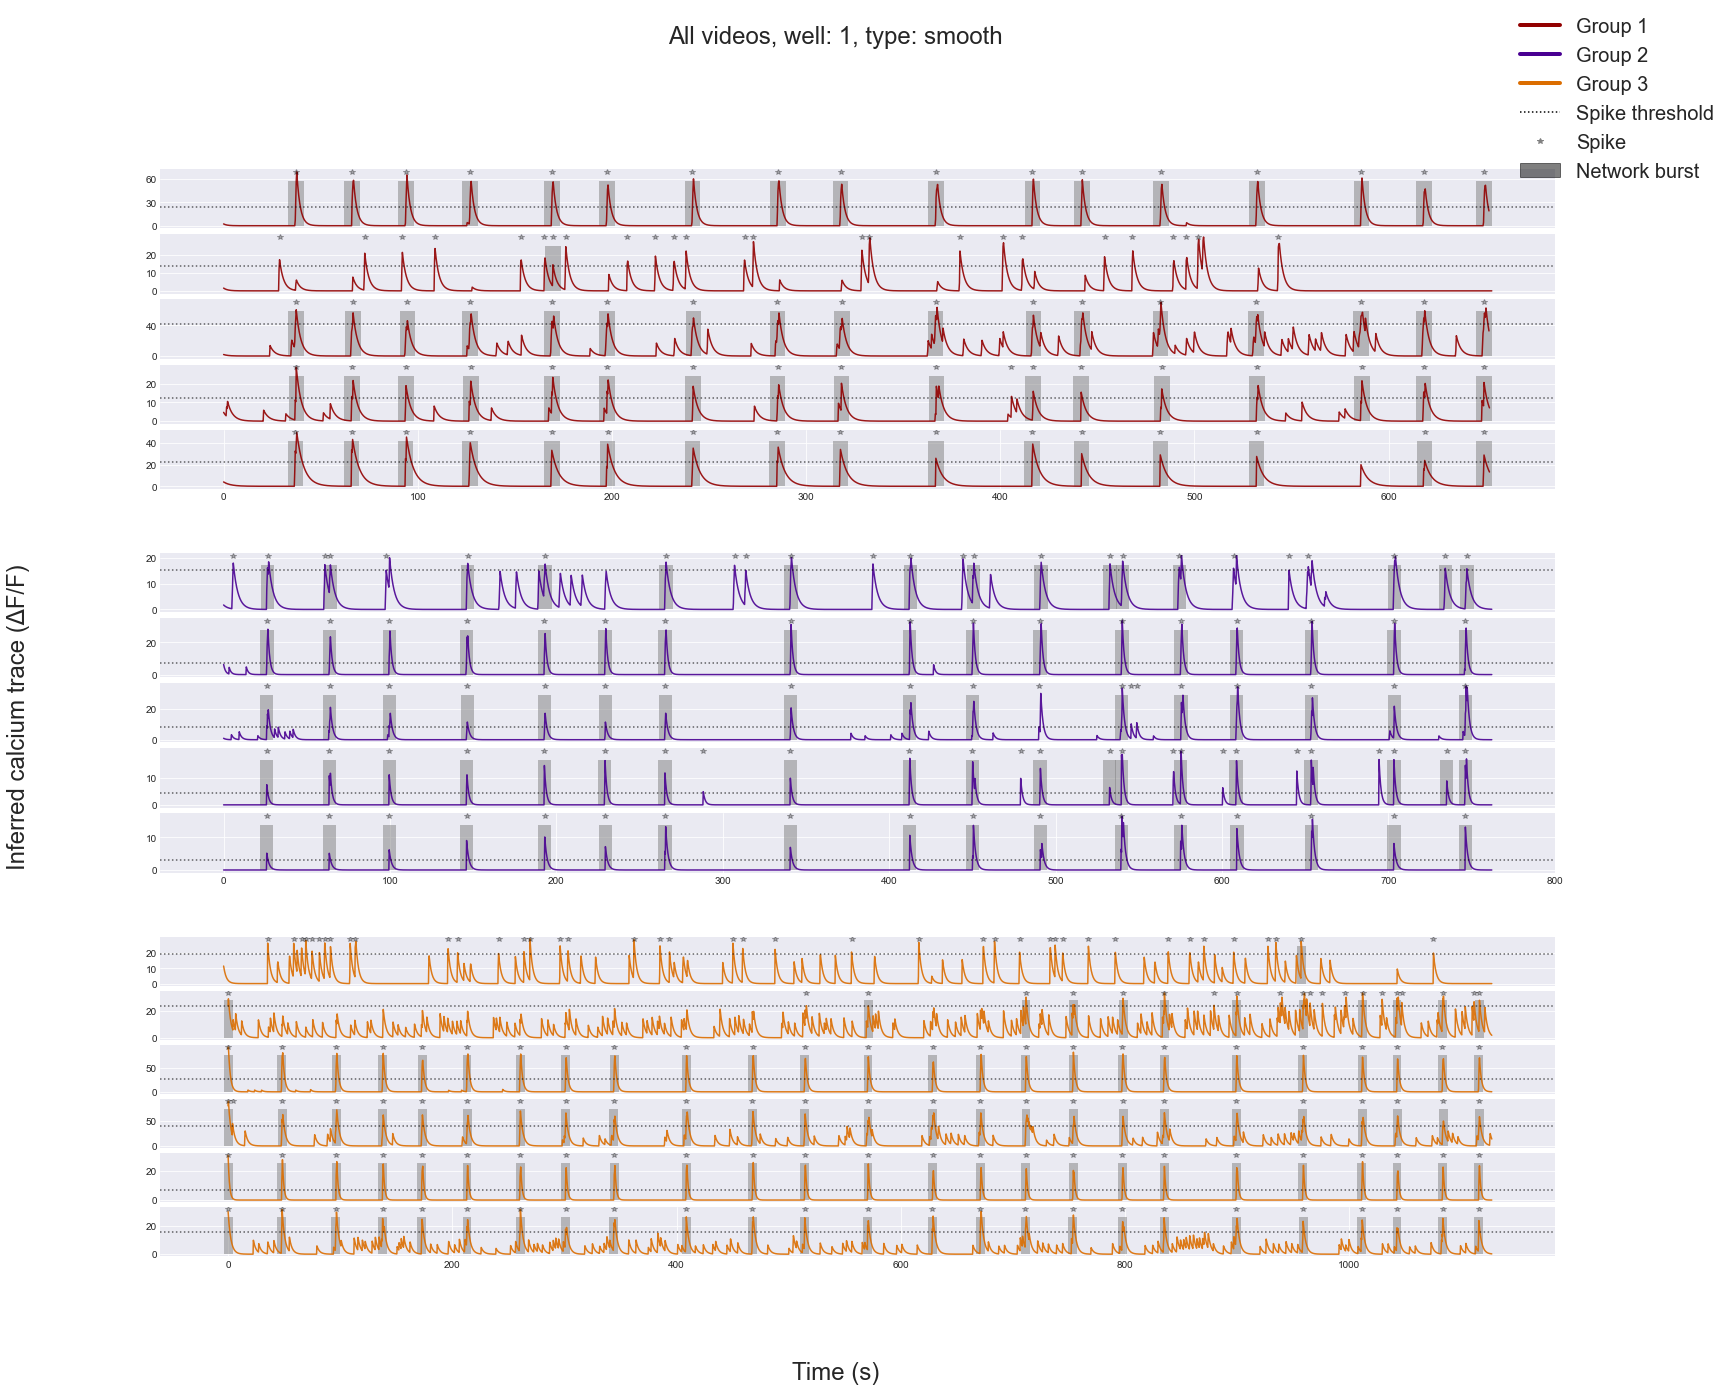

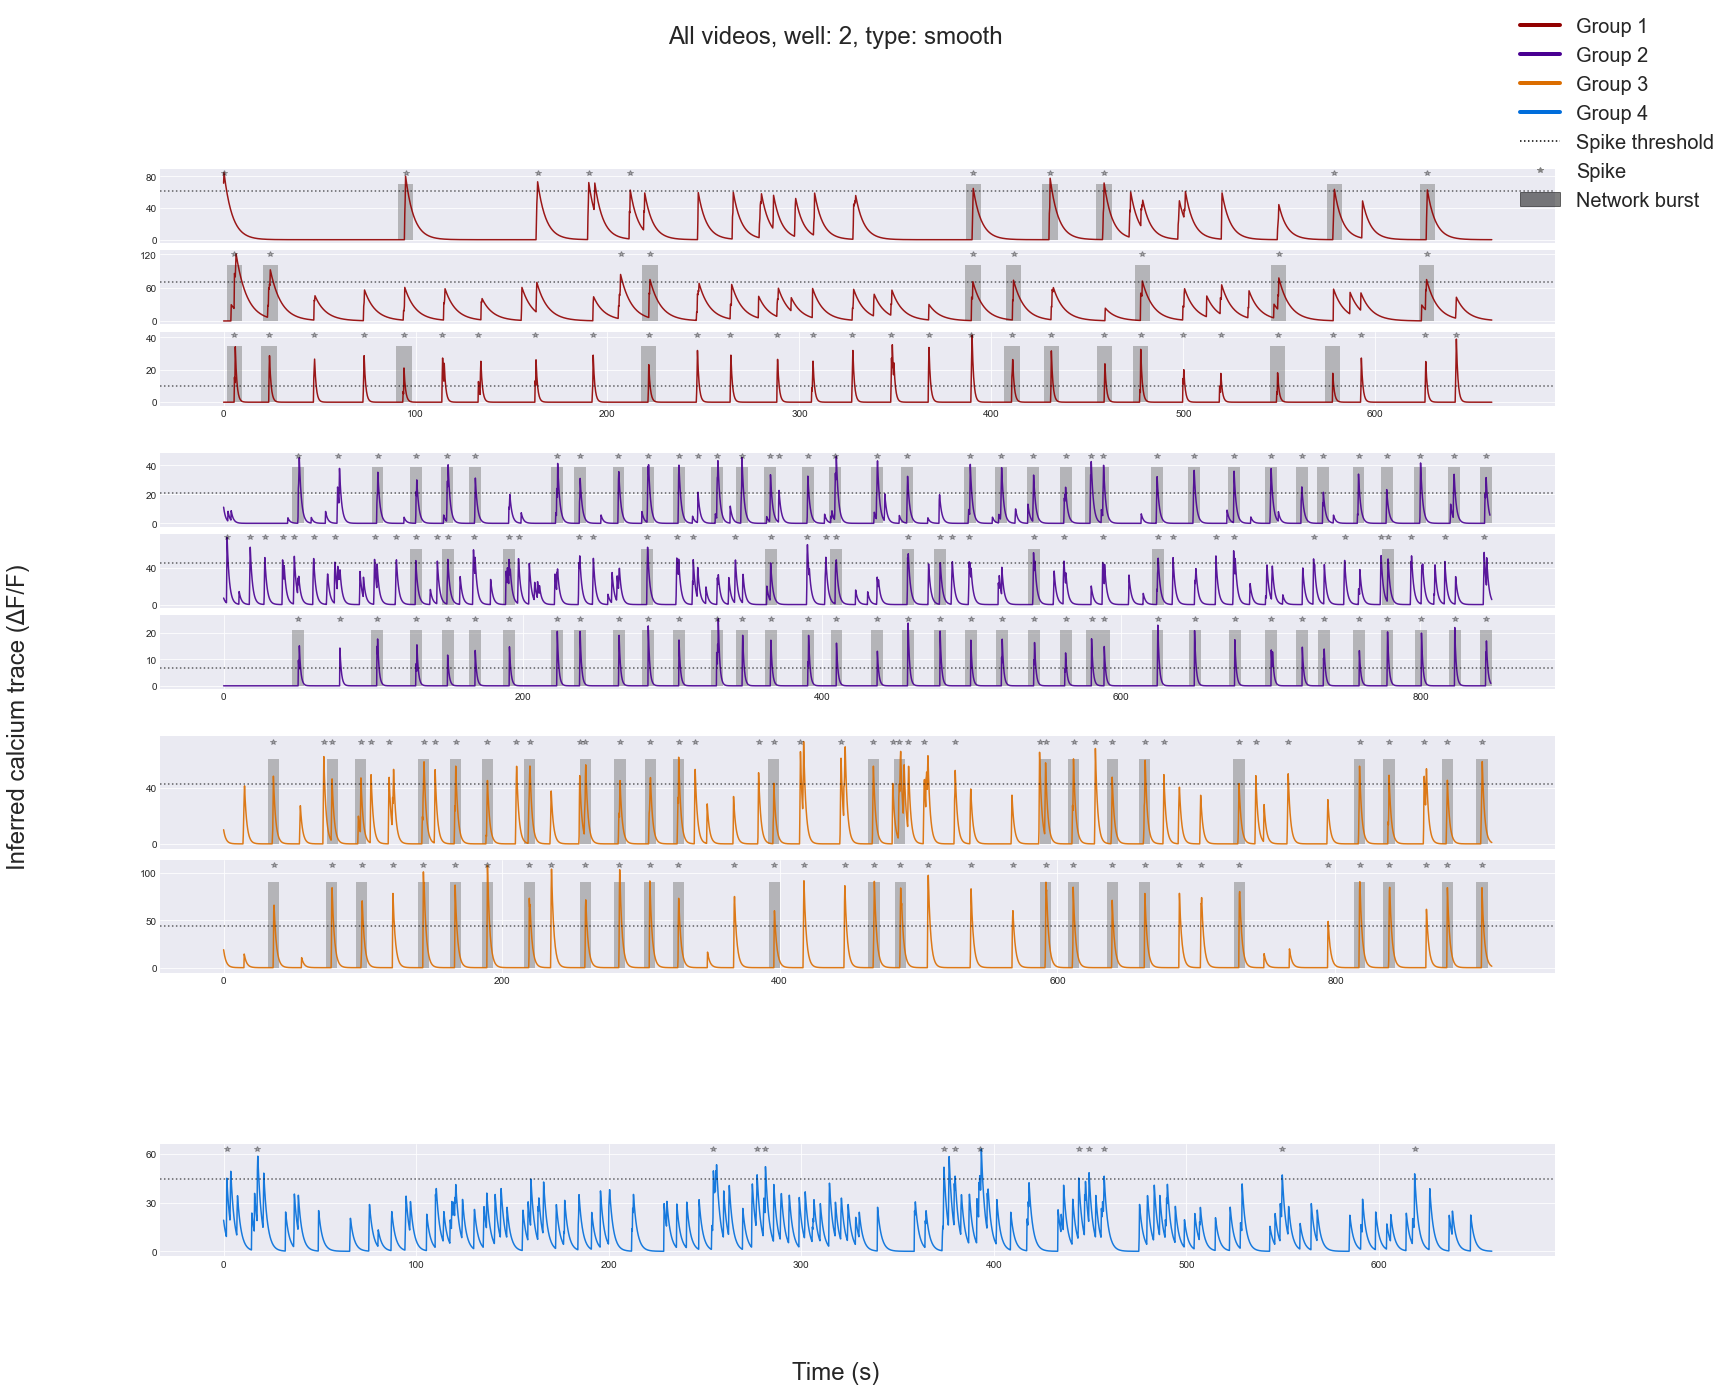

In [8]:
# take final column (trace) and extract it's well to get total amount of wells 
n_wells = int(df.columns[-1].split('.')[0])
data_types = ['smooth'] # DEVNOTE: for now removed 'raw'
# create separate figures for wells and raw/smooth data types 
for n in range(1, n_wells + 1):
    for type in data_types:
        # TODO reinput defaults: define_spikes = to_define_spikes, define_network_bursts = to_define_network_bursts
        plot_traces(df = df, type = type, well = n, spikes = df_spikes, network_bursts = df_network_bursts, thresholds = df_threshold, define_spikes = True, define_network_bursts = True,                         show_equal_trace_length = show_equal_trace_length)
        if to_plot_distributions:
            plot_distribution(df = df, type = type, well = n)

In [28]:
pd_stats = pd.concat([df_stats_spikes, df_stats_network_bursts], axis = 1)

# calculate amount of spikes per group
group_dict = {}
for ind in pd_stats.index:
    well = int(ind.split('.')[0])
    video = int(ind.split('.')[1])
    key = '{}.{}'.format(well, video)
    if key not in group_dict.keys():
        group_dict[key] = 0
    value = pd_stats.loc[ind, 'n_spikes']
    group_dict[key] += value
n_spikes_per_group = []
for ind in pd_stats.index:
    well = int(ind.split('.')[0])
    video = int(ind.split('.')[1])
    key = '{}.{}'.format(well, video)
    n_spikes_per_group.append(group_dict[key])
pd_stats['n_group_spikes'] = n_spikes_per_group

# rename n_spikes to n_trace_spikes specifically for clarity
renamed = list(pd_stats.columns)
renamed[0] = 'n_trace_spikes'
renamed[1] = 'trace_spikes/min'
pd_stats.columns = renamed

print(pd_stats.columns)

# perform summary statistics calculations 
pd_stats['group_spikes/min'] = pd_stats['n_group_spikes'] / (pd_stats['seconds_measured'] / 60)
pd_stats['trace_NBs/min'] = pd_stats['n_trace_NBs'] / (pd_stats['seconds_measured'] / 60)
pd_stats['group_NBs/min'] = pd_stats['n_group_NBs'] / (pd_stats['seconds_measured'] / 60)
pd_stats['trace_spike/trace_NBs'] = pd_stats['n_trace_NBs'] / pd_stats['n_trace_spikes']
pd_stats['group_spike/trace_NBs'] = pd_stats['n_trace_NBs'] / pd_stats['n_group_spikes']
pd_stats['trace_spike/group_NBs'] = pd_stats['n_group_NBs'] / pd_stats['n_trace_spikes']
pd_stats['group_spike/group_NBs'] = pd_stats['n_group_NBs'] / pd_stats['n_group_spikes']

# order dataframe for clarity
pd_stats = pd_stats[['seconds_measured', 'n_trace_spikes', 'n_group_spikes', 'n_trace_NBs', 'n_group_NBs', 
                     'trace_spikes/min', 'group_spikes/min', 'trace_NBs/min', 'group_NBs/min',
                     'trace_spike/trace_NBs', 'group_spike/trace_NBs', 'trace_spike/group_NBs', 'group_spike/group_NBs']]

pd_stats.to_excel('plots/stats.xlsx')

### conclusions
# If nb_time_offset (too) big, 'NBs' are found based on multiple spikes counting from a single trace (should be impossible!)
# Some spikes seem to be very close to the NB but are not plotted as such: example in 1.2.1 4th-last visible double spike peak, because first gets called as spike and spike_offset_time big enough not to call second one as spike as well, second spike actually seems to belong to the NB based on the other traces! 
## similar examples found in orange traces 
# visualize spikes and NBs in one go! 
# need to explain the summary stats and need to discuss which to keep and where to document such that it is clear for users! 

Index(['n_trace_spikes', 'trace_spikes/min', 'seconds_measured', 'n_trace_NBs',
       'n_group_NBs', 'n_group_spikes'],
      dtype='object')


In [ ]:

# Stats documentatie: kopjes in excel moeten toch alles uitleggen :) 
# protocol CNMF-E .xlsx --> input .xlsx
## selecteer 'well x video x' Excel cell
## toetsenboord combinatie: shift + down_arrow, voor alle traces 
## toetsenboord combinatie: shift + control + right_arrow, dan kopiëren (control + c)
## plakken in nieuwe Excel file (control + V), opslaan als bestand met logische naam voor die groep etc
## alle files met wells.videos.X die dan unieke identifiers hebben (X.X.X C/C_raw) kunnen dan in één input folder, deze ingeven bovenaan script 
### als je te veel traces hebt om dit voor te doen kunnen we kijken of ik toch de CNMF-E data op een andere manier als zelfde geheel kan importeren! 

# stappenplan commandos installatie, overdracht code